# Chapter 11 Bayesian Gaussian Processes: rendered figures

Executed preview for browsing on GitHub (static image output, since GitHub's notebook viewer cannot run the interactive JS the live book uses). The source of truth for regenerating the book's figures is `chapter-11-bayesian-gaussian-processes-plots.py`. Run that script directly, not this notebook, to update `_generated/`.

A fitted smoothing spline, from Chapter 6, hands back one curve: the single best estimate of how
latency depends on load, given the requests observed so far. It says nothing about how much that
curve might have looked different if a different sample of requests had been logged instead.

A *Gaussian process*, or *GP*, answers the same curve-fitting question with a full distribution
over curves rather than one winner. That distributional answer means every prediction the GP
makes carries its own built-in statement of how much to trust it.

This chapter works through what that distribution is, how it updates once data arrives, and what
it costs to get.

1. *What does it mean for a distribution to be over functions, not numbers?*
   The idea sounds abstract until it is sampled from directly.
2. *What is a kernel, and what does it control?*
   The kernel is the one modeling choice a Gaussian process asks for, and it decides almost
   everything about the fitted curve's behavior.
3. *How does conditioning on data turn a prior over functions into a posterior?*
   For a Gaussian process, unlike most Bayesian models in this book, the answer has a closed
   form: no MCMC sampling required.
4. *What does the fitted model buy over a smoothing spline?*
   A credible band at every point, not just at the ones near the training data, and an honest
   account of where the model runs out of evidence.

In [1]:
import os
import re
import numpy as np
import plotly.graph_objects as go
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, Matern, WhiteKernel

In [2]:
from IPython.display import Image

pio_width, pio_height = 760, 440

def show(fig: go.Figure, height: int = pio_height) -> Image:
    """Render a Plotly figure as a static PNG for the notebook preview
    (the live book embeds the interactive HTML version instead)."""
    return Image(fig.to_image(format="png", width=pio_width, height=height, scale=1))

## Setup

Random seed and helper functions shared by every figure in this chapter.

In [3]:
RNG = np.random.default_rng(7)

`saturation_curve` is a helper used by the figures below.

In [4]:
def saturation_curve(rho: np.ndarray, base_ms: float = 20.0) -> np.ndarray:
    """Mean latency under an M/M/1-style saturation curve as utilization rho -> 1.
    Matches chapter-06-regression-splines-plots.py's data-generating process."""
    return base_ms / (1.0 - rho)

`simulated_load_latency` is a helper used by the figures below.

In [5]:
def simulated_load_latency(n: int = 30, noise_scale: float = 3.0, rho_max: float = 0.90):
    rho = np.sort(RNG.uniform(0.05, rho_max, size=n))
    mean_latency = saturation_curve(rho)
    latency = mean_latency + RNG.normal(0, noise_scale, size=n)
    return rho, latency

## A prior over functions

Short length-scales produce curves that wiggle rapidly across the full range shown; long length-scales produce curves that barely move across that same range. The slider steps through that whole spectrum, from short to long.

In [6]:
def fig_prior_samples() -> go.Figure:
    x_grid = np.linspace(0, 1, 200).reshape(-1, 1)
    length_scales = [0.03, 0.1, 0.3, 1.0]
    frames = []
    for ls in length_scales:
        gp = GaussianProcessRegressor(kernel=RBF(length_scale=ls), random_state=0)
        samples = gp.sample_y(x_grid, n_samples=5, random_state=1)
        traces = [
            go.Scatter(x=x_grid.ravel(), y=samples[:, i], mode="lines",
                       line=dict(width=1.6), showlegend=False)
            for i in range(samples.shape[1])
        ]
        frames.append(go.Frame(name=f"{ls:.2f}", data=traces))

    fig = go.Figure(data=frames[0].data, frames=frames)
    fig.update_layout(
        title="Five functions sampled from an RBF-kernel GP prior, before any data",
        xaxis_title="x (scaled utilization)",
        yaxis_title="sampled function value",
        sliders=[{
            "active": 0,
            "currentvalue": {"prefix": "length-scale: "},
            "steps": [
                {"label": f.name, "method": "animate",
                 "args": [[f.name], {"mode": "immediate", "frame": {"duration": 300}}]}
                for f in frames
            ],
        }],
        margin=dict(t=60, l=60, r=30, b=50),
    )
    return fig

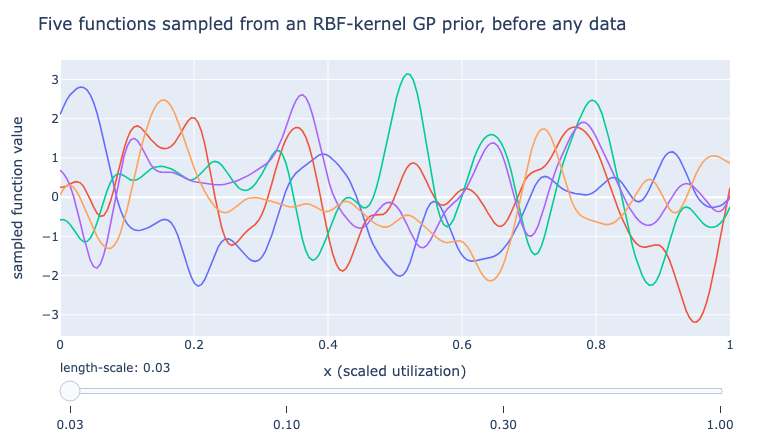

In [7]:
show(fig_prior_samples())

## The kernel: the one modeling choice that matters

The x-axis is scaled utilization and the y-axis is the sampled function value, same as the previous figure. The slider swaps the kernel behind the four sampled curves while holding the length-scale fixed: at the RBF setting shown here, every curve bends smoothly with no sharp corners; switching to Matern nu=1.5 makes the curves visibly jagged; Matern nu=2.5 lands between the two, smoother than nu=1.5 but not as smooth as the RBF curve.

In [8]:
def fig_kernel_comparison() -> go.Figure:
    x_grid = np.linspace(0, 1, 200).reshape(-1, 1)
    kernels = {
        "RBF (infinitely smooth)": RBF(length_scale=0.15),
        "Matern, nu=1.5 (rougher)": Matern(length_scale=0.15, nu=1.5),
        "Matern, nu=2.5 (in between)": Matern(length_scale=0.15, nu=2.5),
    }
    frames = []
    for name, kernel in kernels.items():
        gp = GaussianProcessRegressor(kernel=kernel, random_state=0)
        samples = gp.sample_y(x_grid, n_samples=4, random_state=2)
        traces = [
            go.Scatter(x=x_grid.ravel(), y=samples[:, i], mode="lines",
                       line=dict(width=1.6), showlegend=False)
            for i in range(samples.shape[1])
        ]
        frames.append(go.Frame(name=name, data=traces))

    fig = go.Figure(data=frames[0].data, frames=frames)
    fig.update_layout(
        title="Same length-scale, different kernel: smoothness assumption changes the samples",
        xaxis_title="x (scaled utilization)",
        yaxis_title="sampled function value",
        sliders=[{
            "active": 0,
            "currentvalue": {"prefix": "kernel: "},
            "steps": [
                # Short display labels on purpose: the full kernel names ("RBF
                # (infinitely smooth)", "Matern, nu=2.5 (in between)") overhang past the
                # plot margins at the slider's end positions and get clipped by the plot
                # boundary. Frame names stay unchanged below since the animate() call
                # targets them by name; only the tick label and currentvalue text shorten.
                {"label": label, "method": "animate",
                 "args": [[f.name], {"mode": "immediate", "frame": {"duration": 300}}]}
                for f, label in zip(frames, ["RBF", "Matern 1.5", "Matern 2.5"])
            ],
        }],
        margin=dict(t=60, l=60, r=50, b=50),
    )
    return fig

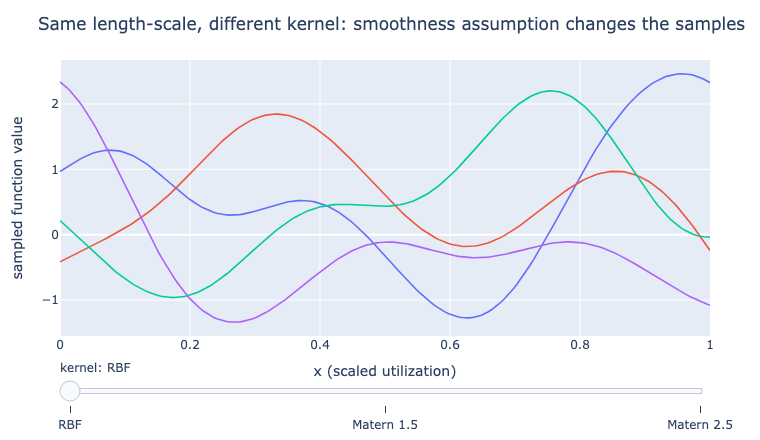

In [9]:
show(fig_kernel_comparison())

## From prior to posterior: conditioning on data

The x-axis is utilization (rho) and the y-axis is latency in milliseconds; the dotted line is the true curve the observations were generated from. At the slider's starting point of five observations, the posterior mean tracks that true curve closely through the smooth, low-utilization part of the range, but the credible band widens sharply above roughly 80% utilization, where the curve bends fastest and the five points give it the least to go on. Dragging the slider toward sixty observations narrows the band further across the whole range, though it never closes all the way at that same high-utilization edge.

In [10]:
def fig_posterior_fit() -> go.Figure:
    rho_full, latency_full = simulated_load_latency(n=60, noise_scale=3.0)
    grid = np.linspace(0.03, 0.92, 250).reshape(-1, 1)
    true_curve = saturation_curve(grid.ravel())
    sample_sizes = [5, 10, 20, 40, 60]
    # rho_full is sorted ascending, so a plain prefix rho_full[:n] would cluster an
    # early, small n entirely among the smallest utilization values (the 5 lowest of
    # 60 uniform draws all land under rho=0.09), leaving the model with no way to show
    # the "closely tracked below ~80% utilization, wide band above it" contrast the
    # chapter text describes. Sampling each n evenly across a growing prefix POOL
    # (85-100% of the sorted range, widening toward the full range as n grows) keeps
    # every subset spread across the covered part of the domain, so the fit stays
    # accurate up to whatever utilization it has seen and only widens beyond that.
    pool_fracs = [0.88, 0.90, 0.93, 0.98, 1.00]
    frames = []
    for n, pool_frac in zip(sample_sizes, pool_fracs):
        pool_hi = max(n - 1, int(round(pool_frac * (len(rho_full) - 1))))
        idx = np.linspace(0, pool_hi, n).astype(int)
        rho_n, lat_n = rho_full[idx], latency_full[idx]
        kernel = RBF(length_scale=0.2, length_scale_bounds=(0.02, 2.0)) + WhiteKernel(1.0)
        gp = GaussianProcessRegressor(kernel=kernel, normalize_y=True, random_state=0)
        gp.fit(rho_n.reshape(-1, 1), lat_n)
        mean, std = gp.predict(grid, return_std=True)
        frames.append(
            go.Frame(
                name=str(n),
                data=[
                    go.Scatter(x=grid.ravel(), y=true_curve, mode="lines", name="true curve",
                                line=dict(color="#999", dash="dot")),
                    go.Scatter(x=np.concatenate([grid.ravel(), grid.ravel()[::-1]]),
                               y=np.concatenate([mean + 1.96 * std, (mean - 1.96 * std)[::-1]]),
                               fill="toself", fillcolor="rgba(76,120,168,0.25)",
                               line=dict(color="rgba(0,0,0,0)"), name="95% credible band",
                               showlegend=True),
                    go.Scatter(x=grid.ravel(), y=mean, mode="lines", name="posterior mean",
                               line=dict(color="#4C78A8", width=2.5)),
                    go.Scatter(x=rho_n, y=lat_n, mode="markers", name="observed",
                               marker=dict(color="#333", size=6)),
                ],
            )
        )

    fig = go.Figure(data=frames[0].data, frames=frames)
    fig.update_layout(
        title="GP posterior mean and 95% credible band as more requests are observed",
        xaxis_title="Utilization (rho)",
        yaxis_title="Latency (ms)",
        yaxis_range=[0, 300],
        sliders=[{
            "active": 0,
            "currentvalue": {"prefix": "observations so far: "},
            "steps": [
                {"label": f.name, "method": "animate",
                 "args": [[f.name], {"mode": "immediate", "frame": {"duration": 300}}]}
                for f in frames
            ],
        }],
        margin=dict(t=60, l=60, r=30, b=50),
    )
    return fig

/Users/Rudrendu/All Mac/project-code/VS_Code/content-system/books-all/open-source-books/Book 3 - Statistics for Data Scientists and Engineers/published-repo/.venv/lib/python3.14/site-packages/sklearn/gaussian_process/kernels.py:445: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


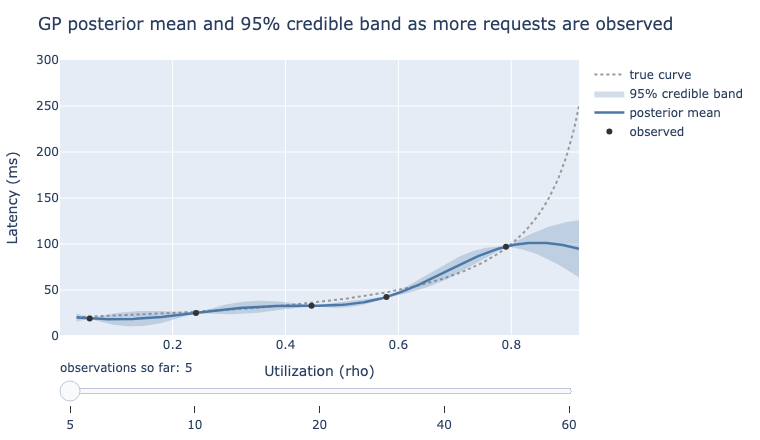

In [11]:
show(fig_posterior_fit())

## From prior to posterior: conditioning on data

Past the shaded boundary, the last utilization observed in this dataset, the posterior mean flattens and drifts down instead of continuing the rising trend. The credible band widens to several times its width just inside that boundary. Both show the model admitting it has no evidence past that point, not a forecast that latency improves at higher load.

In [12]:
def fig_extrapolation() -> go.Figure:
    rho, latency = simulated_load_latency(n=40, noise_scale=3.0, rho_max=0.75)
    grid = np.linspace(0.02, 0.97, 300).reshape(-1, 1)
    kernel = RBF(length_scale=0.2, length_scale_bounds=(0.02, 2.0)) + WhiteKernel(1.0)
    gp = GaussianProcessRegressor(kernel=kernel, normalize_y=True, random_state=0)
    gp.fit(rho.reshape(-1, 1), latency)
    mean, std = gp.predict(grid, return_std=True)

    fig = go.Figure()
    fig.add_vrect(x0=rho.max(), x1=0.97, fillcolor="#F58518", opacity=0.12, line_width=0,
                   annotation_text="beyond observed load range", annotation_position="top left")
    fig.add_trace(go.Scatter(
        x=np.concatenate([grid.ravel(), grid.ravel()[::-1]]),
        y=np.concatenate([mean + 1.96 * std, (mean - 1.96 * std)[::-1]]),
        fill="toself", fillcolor="rgba(76,120,168,0.25)",
        line=dict(color="rgba(0,0,0,0)"), name="95% credible band"))
    fig.add_trace(go.Scatter(x=grid.ravel(), y=mean, mode="lines", name="posterior mean",
                              line=dict(color="#4C78A8", width=2.5)))
    fig.add_trace(go.Scatter(x=rho, y=latency, mode="markers", name="observed",
                              marker=dict(color="#333", size=6)))
    fig.update_layout(
        title="Credible band widens sharply past the highest observed utilization",
        xaxis_title="Utilization (rho)",
        yaxis_title="Latency (ms)",
        yaxis_range=[-50, 500],
        margin=dict(t=60, l=60, r=30, b=50),
    )
    return fig

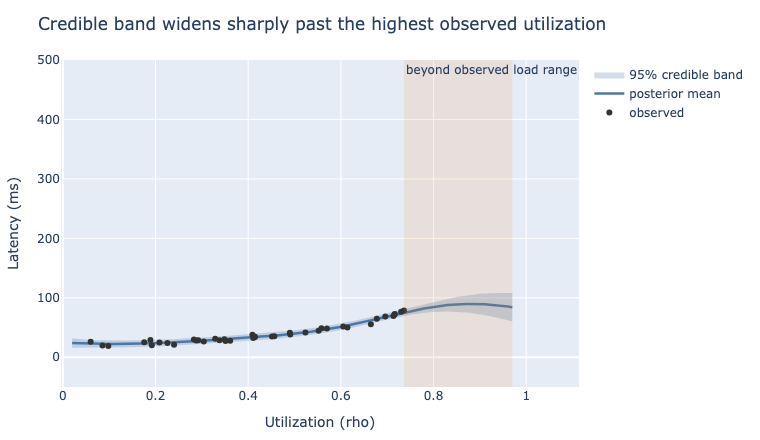

In [13]:
show(fig_extrapolation())

## Choosing the length-scale: marginal likelihood, or a prior on the kernel itself

At the length-scale of 0.02 shown here, too short, the posterior mean (orange) chases individual points. The credible band swells and pinches unevenly along the curve instead of growing smoothly with distance from the data. Drag the slider toward the optimized value from the previous figure to watch both settle down. Push it well past that point instead, and the mean flattens into a near-straight line that misses the saturation bend near high utilization.

In [14]:
def fig_length_scale_fit() -> go.Figure:
    rho, latency = simulated_load_latency(n=45, noise_scale=3.0)
    grid = np.linspace(0.03, 0.92, 250).reshape(-1, 1)
    true_curve = saturation_curve(grid.ravel())
    length_scales = [0.02, 0.08, 0.2, 0.6]
    frames = []
    for ls in length_scales:
        kernel = RBF(length_scale=ls, length_scale_bounds="fixed") + WhiteKernel(1.0)
        gp = GaussianProcessRegressor(kernel=kernel, normalize_y=True, random_state=0)
        gp.fit(rho.reshape(-1, 1), latency)
        mean, std = gp.predict(grid, return_std=True)
        frames.append(
            go.Frame(
                name=f"{ls:.2f}",
                data=[
                    go.Scatter(x=grid.ravel(), y=true_curve, mode="lines", name="true curve",
                                line=dict(color="#999", dash="dot")),
                    go.Scatter(x=np.concatenate([grid.ravel(), grid.ravel()[::-1]]),
                               y=np.concatenate([mean + 1.96 * std, (mean - 1.96 * std)[::-1]]),
                               fill="toself", fillcolor="rgba(229,134,25,0.20)",
                               line=dict(color="rgba(0,0,0,0)"), name="95% credible band"),
                    go.Scatter(x=grid.ravel(), y=mean, mode="lines", name="posterior mean",
                               line=dict(color="#F58518", width=2.5)),
                    go.Scatter(x=rho, y=latency, mode="markers", name="observed",
                               marker=dict(color="#333", size=6)),
                ],
            )
        )

    fig = go.Figure(data=frames[0].data, frames=frames)
    fig.update_layout(
        title="A fixed length-scale can under-fit (too long) or chase noise (too short)",
        xaxis_title="Utilization (rho)",
        yaxis_title="Latency (ms)",
        yaxis_range=[0, 300],
        sliders=[{
            "active": 0,
            "currentvalue": {"prefix": "length-scale (held fixed, not optimized): "},
            "steps": [
                {"label": f.name, "method": "animate",
                 "args": [[f.name], {"mode": "immediate", "frame": {"duration": 300}}]}
                for f in frames
            ],
        }],
        margin=dict(t=60, l=60, r=30, b=50),
    )
    return fig

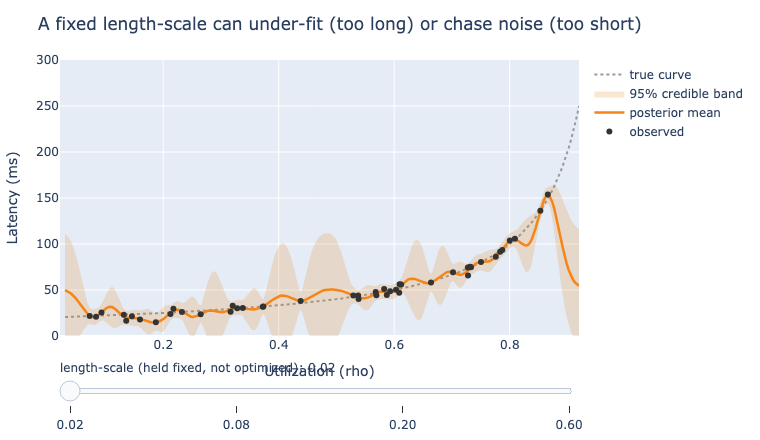

In [15]:
show(fig_length_scale_fit())

## More than one input at a time

Two predictors, payload size and concurrent-request utilization, on inputs standardized to the same scale so the two length-scales are directly comparable. Concurrent-request utilization fits a length-scale under 1, since latency swings sharply as utilization approaches capacity. Payload size fits a length-scale over 20, since latency barely moves across its whole observed range once utilization is accounted for.

In [16]:
def fig_ard_length_scales() -> go.Figure:
    """"More than one input at a time" explains that a fitted length-scale per
    dimension is itself a variable-importance signal, but the section had no chart to
    show it. This fits a two-predictor GP (payload size and concurrent-request
    utilization predicting latency, the pairing @fig-posterior-fit and this chapter's
    Chapter-4 callback both use) with an automatic-relevance-determination kernel and
    plots the two fitted length-scales side by side, on inputs standardized to the same
    scale so the two numbers are directly comparable."""
    n = 80
    payload_kb = RNG.uniform(2, 20, n)
    concurrent_util = RNG.uniform(0.05, 0.85, n)
    latency = saturation_curve(concurrent_util) + 0.3 * payload_kb + RNG.normal(0, 3, n)

    X = np.column_stack([payload_kb, concurrent_util])
    X_norm = (X - X.mean(axis=0)) / X.std(axis=0)

    kernel = RBF(length_scale=[1.0, 1.0], length_scale_bounds=(0.05, 100.0)) + WhiteKernel(1.0)
    gp = GaussianProcessRegressor(kernel=kernel, normalize_y=True, n_restarts_optimizer=8,
                                   random_state=0)
    gp.fit(X_norm, latency)
    fitted_length_scales = gp.kernel_.k1.length_scale

    labels = ["payload size", "concurrent-request<br>utilization"]
    fig = go.Figure(go.Bar(
        x=labels, y=fitted_length_scales, marker_color=["#4C78A8", "#F58518"],
        text=[f"{v:.2f}" for v in fitted_length_scales], textposition="outside",
    ))
    fig.update_layout(
        title="Fitted ARD length-scale per predictor (standardized inputs)",
        yaxis_title="Fitted length-scale",
        margin=dict(t=60, l=60, r=30, b=50),
    )
    return fig

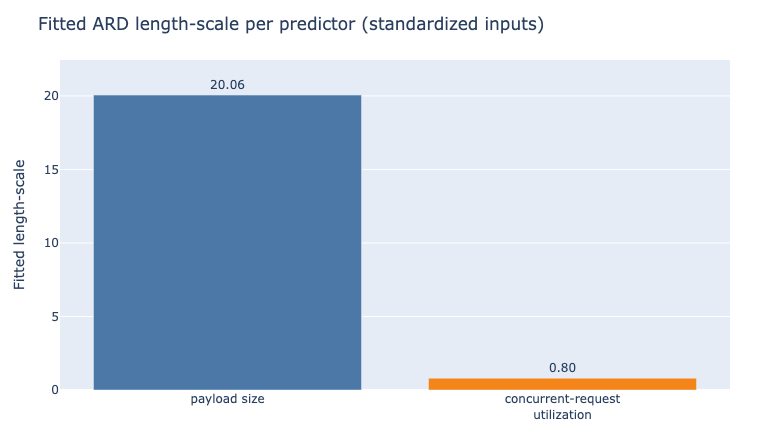

In [17]:
show(fig_ard_length_scales())